In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(root) not in sys.path:
    sys.path.append(str(root))

from src.preprocessing.clean import load_events_csv

HOUSE = os.environ.get("SMART_HOME_HOUSE", "hh101")
raw_path = root / "data" / "raw" / f"{HOUSE}.csv"
if not raw_path.exists():
    raise FileNotFoundError(f"Raw dataset not found: {raw_path}")

fig_dir = root / "outputs" / "figures" / HOUSE
table_dir = root / "outputs" / "tables" / HOUSE
fig_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

events = load_events_csv(str(raw_path))
print(f"Loaded {len(events)} events for {HOUSE} from {raw_path}")
events.head(), events["sensor"].nunique()

Loaded 1286243 events for hh101 from C:\Users\evang\Documents\GitHub\smart-home-anomaly-detection\data\raw\hh101.csv


(         date                  timestamp       sensor value
 0  2012-07-18 2012-07-18 12:54:45.196564  OutsideDoor  OPEN
 1  2012-07-18 2012-07-18 12:54:45.682577      Kitchen   OFF
 2  2012-07-18 2012-07-18 12:54:45.723461     Bathroom  OPEN
 3  2012-07-18 2012-07-18 12:54:45.767498      Bedroom    ON
 4  2012-07-18 2012-07-18 12:54:45.951482   LivingRoom    ON,
 6)

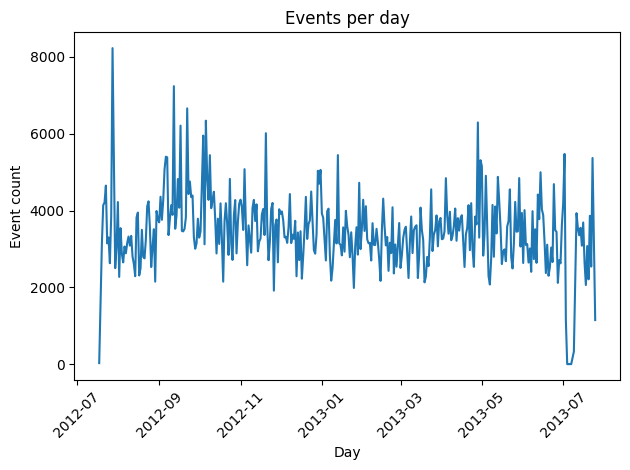

In [2]:
# Events per day
events["day"] = events["timestamp"].dt.date
counts = events.groupby("day").size()
counts.to_csv(table_dir / f"{HOUSE}_events_per_day.csv", header=["event_count"])

plt.figure()
plt.plot(counts.index, counts.values)
plt.title("Events per day")
plt.xlabel("Day")
plt.ylabel("Event count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(fig_dir / f"{HOUSE}_events_per_day.png", bbox_inches="tight")
plt.show()

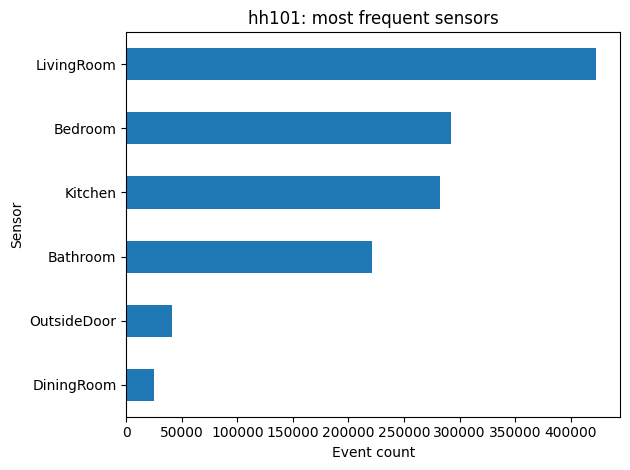

sensor
LivingRoom     423313
Bedroom        292142
Kitchen        282515
Bathroom       221514
OutsideDoor     41421
DiningRoom      25338
Name: count, dtype: int64

In [3]:
# Most frequent sensors
top = events["sensor"].value_counts().head(15)
top.to_csv(table_dir / f"{HOUSE}_top_sensors.csv", header=["count"])

plt.figure()
top.sort_values().plot(kind="barh")
plt.title(f"{HOUSE}: most frequent sensors")
plt.xlabel("Event count")
plt.ylabel("Sensor")
plt.tight_layout()
plt.savefig(fig_dir / f"{HOUSE}_top_sensors.png", bbox_inches="tight")
plt.show()

top

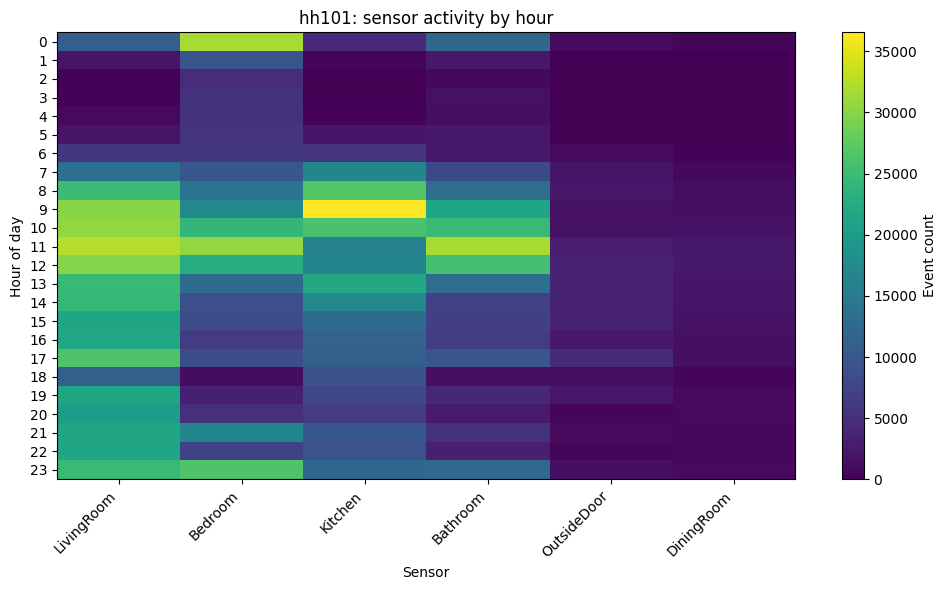

sensor,LivingRoom,Bedroom,Kitchen,Bathroom,OutsideDoor,DiningRoom
hour,,,,,,
0,11012,31751,4524,12414,1013,580
1,2047,9493,684,2497,264,86
2,194,4644,104,814,34,8
3,298,5334,76,1576,56,0
4,978,5289,380,1464,168,26


In [4]:
# Sensor-by-hour heatmap
sensor_hour = (
    events.assign(hour=pd.to_datetime(events["timestamp"]).dt.hour)
    .groupby(["hour", "sensor"])
    .size()
    .unstack(fill_value=0)
    .reindex(range(24), fill_value=0)
)
sensor_hour = sensor_hour.reindex(sensor_hour.sum().sort_values(ascending=False).index, axis=1)
sensor_hour.to_csv(table_dir / f"{HOUSE}_sensor_hour_matrix.csv")

plt.figure(figsize=(10, 6))
plt.imshow(sensor_hour.values, aspect="auto", cmap="viridis")
plt.title(f"{HOUSE}: sensor activity by hour")
plt.xlabel("Sensor")
plt.ylabel("Hour of day")
plt.xticks(range(len(sensor_hour.columns)), sensor_hour.columns, rotation=45, ha="right")
plt.yticks(range(24), sensor_hour.index)
plt.colorbar(label="Event count")
plt.tight_layout()
plt.savefig(fig_dir / f"{HOUSE}_sensor_hour_heatmap.png", bbox_inches="tight")
plt.show()

sensor_hour.head()